<a href="https://colab.research.google.com/github/ankitta-singh/machinelearning/blob/main/%2002_EDA_and_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()


Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip


In [3]:
import zipfile

with zipfile.ZipFile("house-prices-advanced-regression-techniques.zip", "r") as zip_ref:
    zip_ref.extractall("house_data")

In [43]:
import os
print(os.listdir("house_data"))

['train.csv', 'test.csv', 'data_description.txt', 'sample_submission.csv']


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [45]:
df = pd.read_csv("house_data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


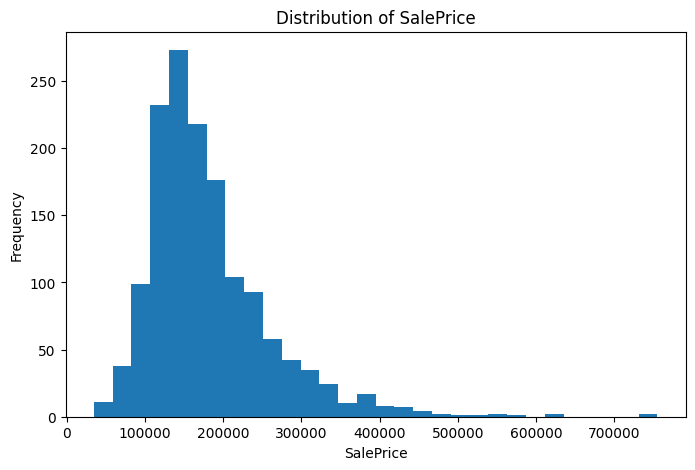

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["SalePrice"], bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [9]:
print(df["SalePrice"].skew())

1.8828757597682129


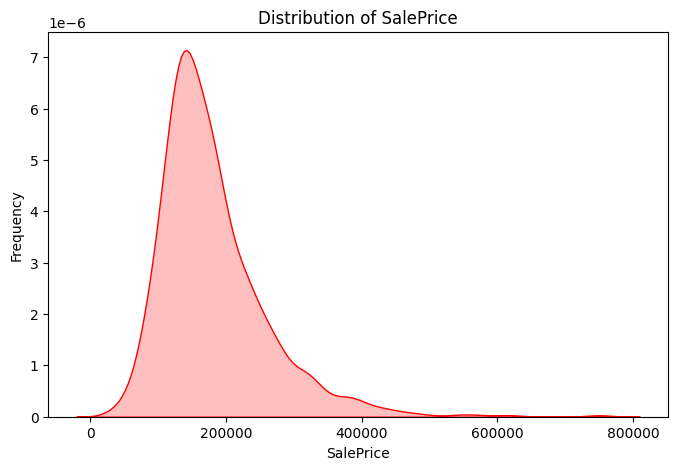

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(df["SalePrice"], fill=True, color="red")
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [48]:
import numpy as np

df["LogSalePrice"] = np.log1p(df["SalePrice"])

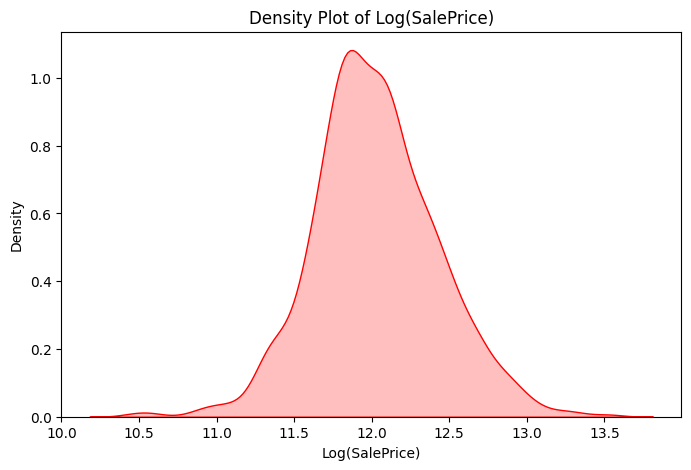

In [49]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["LogSalePrice"], fill=True, color="red")

plt.title("Density Plot of Log(SalePrice)")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Density")

plt.show()

<Axes: ylabel='SalePrice'>

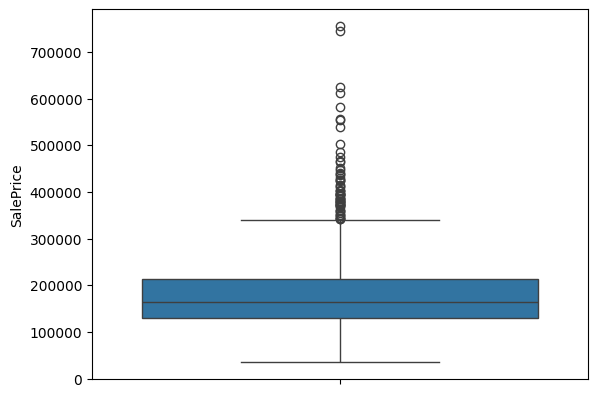

In [50]:
sns.boxplot(df["SalePrice"])

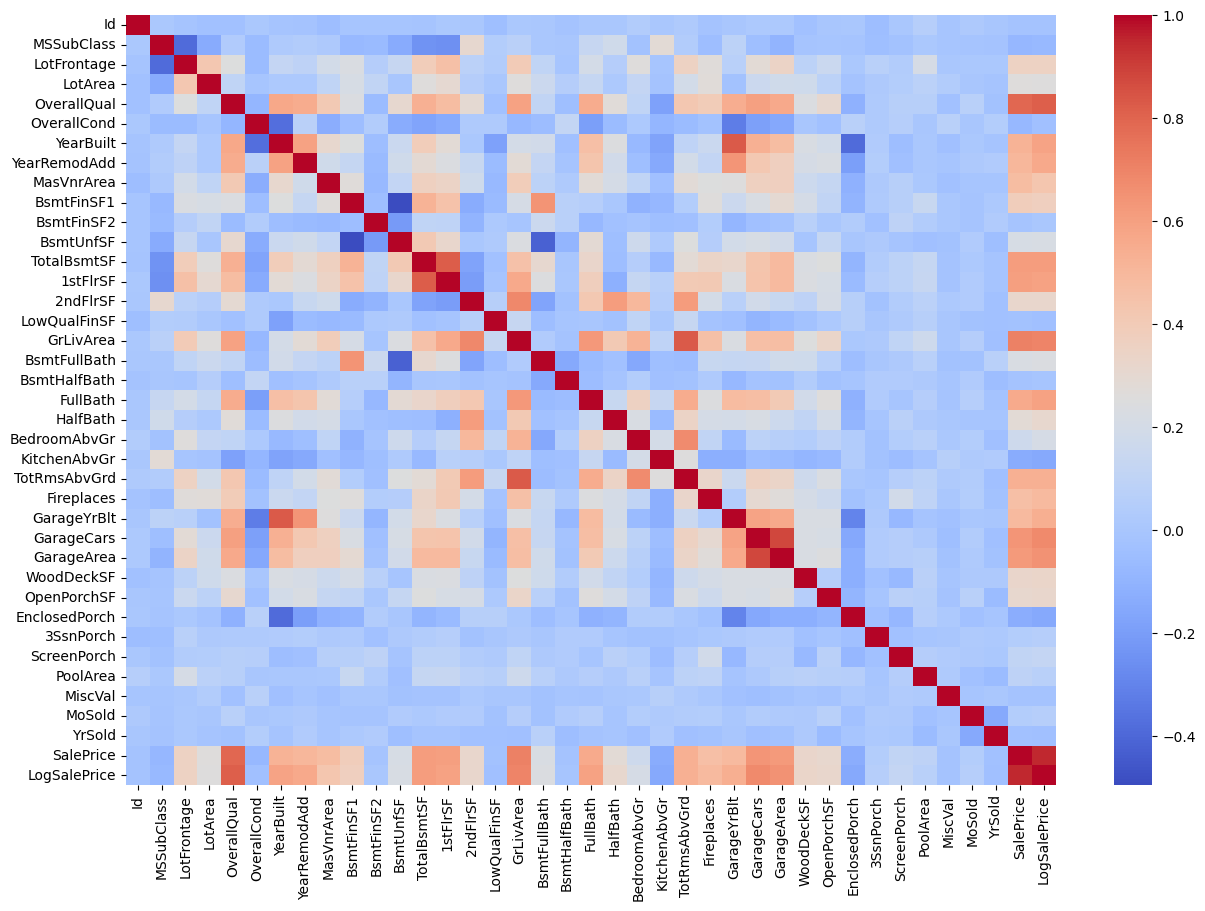

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()


In [52]:
corr["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
LogSalePrice,0.948374
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723


In [53]:
corr.loc["GarageCars", "GarageArea"]

np.float64(0.882475414281462)

In [54]:
features_original = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd"
]

In [55]:
features = features_original.copy()
features.remove("GarageCars")

X = df[features]
y = df["SalePrice"]

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [58]:
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("GarageArea Removed")
print("=" * 40)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

GarageArea Removed
MAE : 24551.059183344376
RMSE: 39515.86924328583
R2  : 0.7964227491929446


In [60]:
corr = df.corr(numeric_only=True)

high_corr = corr.abs()

high_corr

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,LogSalePrice
Id,1.000000,0.011156,0.010601,0.033226,0.028365,0.012609,0.012713,0.021998,0.050298,0.005024,...,0.000477,0.002889,0.046635,0.001330,0.057044,0.006242,0.021172,0.000712,0.021917,0.017942
MSSubClass,0.011156,1.000000,0.386347,0.139781,0.032628,0.059316,0.027850,0.040581,0.022936,0.069836,...,0.006100,0.012037,0.043825,0.026030,0.008283,0.007683,0.013585,0.021407,0.084284,0.073959
LotFrontage,0.010601,0.386347,1.000000,0.426095,0.251646,0.059213,0.123349,0.088866,0.193458,0.233633,...,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799,0.355879
LotArea,0.033226,0.139781,0.426095,1.000000,0.105806,0.005636,0.014228,0.013788,0.104160,0.214103,...,0.084774,0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,0.014261,0.263843,0.257320
OverallQual,0.028365,0.032628,0.251646,0.105806,1.000000,0.091932,0.572323,0.550684,0.411876,0.239666,...,0.308819,0.113937,0.030371,0.064886,0.065166,0.031406,0.070815,0.027347,0.790982,0.817185
OverallCond,0.012609,0.059316,0.059213,0.005636,0.091932,1.000000,0.375983,0.073741,0.128101,0.046231,...,0.032589,0.070356,0.025504,0.054811,0.001985,0.068777,0.003511,0.043950,0.077856,0.036868
YearBuilt,0.012713,0.027850,0.123349,0.014228,0.572323,0.375983,1.000000,0.592855,0.315707,0.249503,...,0.188686,0.387268,0.031355,0.050364,0.004950,0.034383,0.012398,0.013618,0.522897,0.586570
YearRemodAdd,0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.226298,0.193919,0.045286,0.038740,0.005829,0.010286,0.021490,0.035743,0.507101,0.565608
MasVnrArea,0.050298,0.022936,0.193458,0.104160,0.411876,0.128101,0.315707,0.179618,1.000000,0.264736,...,0.125703,0.110204,0.018796,0.061466,0.011723,0.029815,0.005965,0.008201,0.477493,0.430809
BsmtFinSF1,0.005024,0.069836,0.233633,0.214103,0.239666,0.046231,0.249503,0.128451,0.264736,1.000000,...,0.111761,0.102303,0.026451,0.062021,0.140491,0.003571,0.015727,0.014359,0.386420,0.372023


In [25]:
import numpy as np

corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.80
]

high_corr

[('1stFlrSF', 'TotalBsmtSF', np.float64(0.8195299750050339)),
 ('TotRmsAbvGrd', 'GrLivArea', np.float64(0.8254893743088425)),
 ('GarageYrBlt', 'YearBuilt', np.float64(0.8256674841743408)),
 ('GarageArea', 'GarageCars', np.float64(0.882475414281462)),
 ('LogSalePrice', 'OverallQual', np.float64(0.8171846144867677)),
 ('LogSalePrice', 'SalePrice', np.float64(0.9483743770902764))]

In [61]:
df["LogSalePrice"] = np.log(df["SalePrice"])

In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.0,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.0,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.0,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.0,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.0,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.0,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.0,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.0,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.0,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


In [63]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

MSZoning: 5 unique values
Street: 2 unique values
Alley: 2 unique values
LotShape: 4 unique values
LandContour: 4 unique values
Utilities: 2 unique values
LotConfig: 5 unique values
LandSlope: 3 unique values
Neighborhood: 25 unique values
Condition1: 9 unique values
Condition2: 8 unique values
BldgType: 5 unique values
HouseStyle: 8 unique values
RoofStyle: 6 unique values
RoofMatl: 8 unique values
Exterior1st: 15 unique values
Exterior2nd: 16 unique values
MasVnrType: 3 unique values
ExterQual: 4 unique values
ExterCond: 5 unique values
Foundation: 6 unique values
BsmtQual: 4 unique values
BsmtCond: 4 unique values
BsmtExposure: 4 unique values
BsmtFinType1: 6 unique values
BsmtFinType2: 6 unique values
Heating: 6 unique values
HeatingQC: 5 unique values
CentralAir: 2 unique values
Electrical: 5 unique values
KitchenQual: 4 unique values
Functional: 7 unique values
FireplaceQu: 5 unique values
GarageType: 6 unique values
GarageFinish: 3 unique values
GarageQual: 5 unique values
Garag

In [65]:
from scipy.stats import ttest_ind

yes_price = df[df["CentralAir"] == "Y"]["SalePrice"]
no_price = df[df["CentralAir"] == "N"]["SalePrice"]

t_stat, p_value = ttest_ind(yes_price, no_price)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 9.914905121389344
P-value: 1.8095061559266025e-22


In [66]:
print("Mean SalePrice (CentralAir = Yes):", yes_price.mean())
print("Mean SalePrice (CentralAir = No):", no_price.mean())

Mean SalePrice (CentralAir = Yes): 186186.7098901099
Mean SalePrice (CentralAir = No): 105264.07368421053


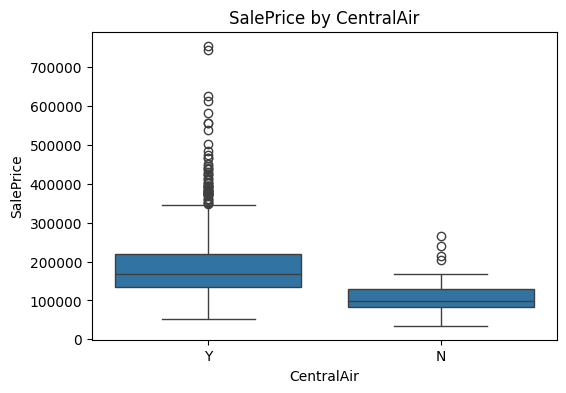

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="CentralAir", y="SalePrice", data=df)
plt.title("SalePrice by CentralAir")
plt.show()

In [68]:
from sklearn.model_selection import train_test_split

x_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [69]:
X_train, X_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42
)

In [70]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (934, 9)
Validation: (234, 9)
Test: (292, 9)


In [71]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [73]:
y_val_pred = model.predict(X_val)

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Validation Results")
print("MAE :", mean_absolute_error(y_val, y_val_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("R2  :", r2_score(y_val, y_val_pred))

Validation Results
MAE : 23751.627719885517
RMSE: 35185.995399153595
R2  : 0.8084637030634132


In [75]:
y_test_pred = model.predict(X_test)

print("Test Results")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2  :", r2_score(y_test, y_test_pred))

Test Results
MAE : 24602.21746482577
RMSE: 40134.25695818629
R2  : 0.7900012935464937


In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

In [79]:
param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]

}

In [80]:
grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid,
    scoring="r2",
    cv=5
)

In [81]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring='r2')

In [82]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'fit_intercept': True, 'positive': True}


In [83]:
print("Best CV R2 Score:")
print(grid.best_score_)

Best CV R2 Score:
0.7351553064920273


In [87]:
print(grid.best_params_)
print(grid.best_score_)

{'fit_intercept': True, 'positive': True}
0.7351553064920273
